# Steganography using Bit-Plane Slicing in Python

## This implementation hides a secret grayscale image inside the least significant bit (LSB) of a cover image using bit-plane slicing.

## The cover image’s 7 most significant bits are preserved.

## The secret image’s most significant bit is embedded into the cover’s LSB.

## The stego image looks visually identical to the cover, but the secret can be recovered.

## This method demonstrates a basic LSB steganography approach, widely used in information hiding.

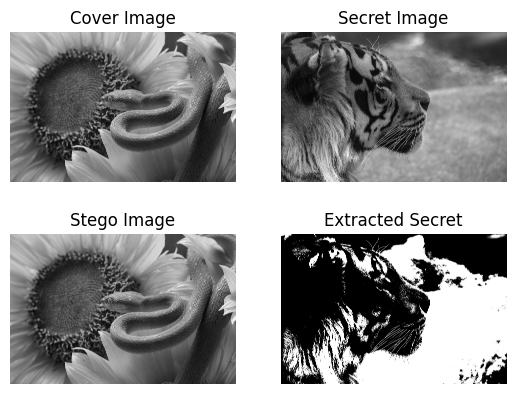

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------- Load Cover and Secret Images --------
cover = cv2.imread("cover.png", cv2.IMREAD_GRAYSCALE)   # Large image
secret = cv2.imread("secret.png", cv2.IMREAD_GRAYSCALE) # Small image

# Resize secret to fit cover
secret = cv2.resize(secret, (cover.shape[1], cover.shape[0]))

# -------- Hide Secret in Cover using LSB --------
# Take 7 MSBs of cover
cover_msb = np.bitwise_and(cover, 0b11111110)

# Take 1 MSB of secret, shift to LSB
secret_bit = np.right_shift(secret, 7)

# Combine both
stego = cover_msb | secret_bit

# -------- Extract Secret --------
# Extract LSB and shift back to MSB
extracted = np.left_shift(np.bitwise_and(stego, 1), 7)

# -------- Display Results --------
titles = ['Cover Image', 'Secret Image', 'Stego Image', 'Extracted Secret']
images = [cover, secret, stego, extracted]

for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()
